In [13]:
get_fitted_model_names(session_name='ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36')

['QLearning_L1F0_CKfull_softmax',
 'WSLS',
 'QLearning_L2F1_softmax',
 'QLearning_L1F0_epsi',
 'ForagingCompareThreshold',
 'QLearning_L1F1_CK1_softmax',
 'QLearning_L2F1_CKfull_softmax',
 'QLearning_L1F1_CKfull_softmax']

In [20]:
a=get_fitted_latent(session_name='ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36',model_alias='QLearning_L2F1_CKfull_softmax')

In [23]:
a['results']

_id                                             dc6f5eebc675981569eafdad20a7334f207e2a433d0300...
nwb_name                                                           795393_2025-09-15_13-05-25.nwb
session_date                                                                           2025-09-15
status                                                                                    success
subject_id                                                                                 795393
agent_alias                                                         QLearning_L2F1_CKfull_softmax
log_likelihood                                                                        -246.034918
AIC                                                                                    506.069836
BIC                                                                                     536.56259
LPT                                                                                       0.65237
LPT_AIC             

In [2]:
summary['auto_train_stage']

0    STAGE_FINAL
Name: auto_train_stage, dtype: object

In [1]:
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()
from behavior_qc_visualization import collect_behavior_model_summary
summary=collect_behavior_model_summary(session_paths=['/root/capsule/data/general_behavior/812561/812561_2025-10-25_17-37-30.nwb'])

Found behavior NWB: /root/capsule/data/general_behavior/812561/812561_2025-10-25_17-37-30.nwb
Successfully read behavior NWB from: /root/capsule/data/general_behavior/812561/812561_2025-10-25_17-37-30.nwb
No entries for alias 'QLearning_L2F1_CK1_softmax' in fit results
No entries for alias 'QLearning_L2F1_CK1_softmax' in fit results


In [ ]:
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()
from behavior_qc_visualization import collect_behavior_model_summary
summary=collect_behavior_model_summary(sessions=sessions)

In [8]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

from behavior_qc_visualization import collect_behavior_model_summary
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()


def _run_one_session(session_name: str) -> pd.DataFrame:
    # If collect_behavior_model_summary can accept a single-session list, reuse it.
    # This keeps behavior identical to your existing function.
    df = collect_behavior_model_summary(sessions=[session_name])
    # Optional: add session column if it's not already present
    if "session_name" not in df.columns:
        df = df.assign(session_name=session_name)
    return df

def collect_behavior_model_summary_parallel(
    sessions,
    *,
    max_workers: int = 8,
) -> pd.DataFrame:
    dfs = []
    errors = []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        fut_to_sess = {ex.submit(_run_one_session, s): s for s in sessions}
        for fut in as_completed(fut_to_sess):
            s = fut_to_sess[fut]
            try:
                dfs.append(fut.result())
            except Exception as e:
                errors.append((s, repr(e)))

    if errors:
        # Don't crash everything; return what you got + a helpful report
        print("Some sessions failed:")
        for s, err in errors[:20]:
            print(f"  {s}: {err}")
        if len(errors) > 20:
            print(f"  ... plus {len(errors)-20} more")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True, sort=False)

    # Optional: stable ordering if you want
    if "session_name" in out.columns:
        out = out.sort_values(["session_name"]).reset_index(drop=True)

    return out

# Usage
summary = collect_behavior_model_summary_parallel(sessions, max_workers=8)


Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-09_10-50-19.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753124_2024-12-10_17-24-56.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-10_14-41-23.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-14_15-37-15.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-15_16-16-22.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753126_2024-10-11_13-14-24.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753126_2024-10-10_17-51-24.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753126_2024-10-15_12-20-35.nwb


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/753125_2024-10-14_15-37-15.nwb


In [1]:
import os

# Define the root directory (based on the folder structure you provided)
root_dir = "/root/capsule/data/general_behavior/"

# Initialize a list to store the full paths of all .nwb files
nwb_files = []

# Walk through all directories and files under the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".nwb"):
            # Append the full path of each .nwb file
            nwb_files.append(os.path.join(root, file))


import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
from tqdm import tqdm  # Import tqdm for progress bar
from behavior_qc_visualization import collect_behavior_model_summary
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent

def _run_one_session(session_name: str) -> pd.DataFrame:
    df = collect_behavior_model_summary(session_paths=[session_name])
    if "session_name" not in df.columns:
        df = df.assign(session_name=session_name)
    return df

def collect_behavior_model_summary_parallel(
    session_paths,
    *,
    max_workers: int = 20,
) -> pd.DataFrame:
    dfs = []
    errors = []
    total_sessions = len(session_paths)
    
    # Initialize tqdm progress bar
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        fut_to_sess = {ex.submit(_run_one_session, s): s for s in session_paths}
        completed = 0  # Initialize the completed task counter
        
        # Wrap the as_completed in tqdm to show progress
        for fut in tqdm(as_completed(fut_to_sess), total=total_sessions, desc="Processing sessions", ncols=100):
            completed += 1  # Increment completed tasks count
            
            s = fut_to_sess[fut]
            
            try:
                dfs.append(fut.result())
            except Exception as e:
                errors.append((s, repr(e)))

    if errors:
        print("Some sessions failed:")
        for s, err in errors[:20]:
            print(f"  {s}: {err}")
        if len(errors) > 20:
            print(f"  ... plus {len(errors)-20} more")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True, sort=False)

    if "session_name" in out.columns:
        out = out.sort_values(["session_name"]).reset_index(drop=True)

    return out

# Usage
summary = collect_behavior_model_summary_parallel(session_paths=nwb_files, max_workers=8)


# Save the summary to a CSV file in /root/capsule/scratch
output_path = '/root/capsule/scratch/behavior_model_summary.csv'
summary.to_csv(output_path, index=False)  # Save without the index column
print(f"Summary saved to {output_path}")




Found behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-14_14-17-39.nwbFound behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-13_14-14-22.nwb

Found behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-07_14-24-02.nwb
Found behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-19_14-28-21.nwb
Found behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-10_12-37-32.nwb
Found behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-21_16-35-05.nwb
Found behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-18_13-37-16.nwb
Found behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-03_13-45-54.nwb


Processing sessions:   0%|                                                 | 0/5176 [00:00<?, ?it/s]

Successfully read behavior NWB from: /root/capsule/data/general_behavior/816786/816786_2025-11-13_14-14-22.nwb
Found 8 MLE fitting records!
Found 8 successful MLE fitting!
Found 8 MLE fitting records!
No entries for alias 'QLearning_L2F1_CK1_softmax' in fit results
No entries for alias 'QLearning_L2F1_CK1_softmax' in fit results


Processing sessions:   0%|                                       | 6/5176 [00:20<2:30:34,  1.75s/it]

Found behavior NWB: /root/capsule/data/general_behavior/816786/816786_2025-11-23_16-14-41.nwb
Found 16 MLE fitting records!
Duplicated agent_alias!
There are multiple nwbs for this session:
['816786_2025-11-21_16-35-05.nwb' '816786_2025-11-21_14-24-05.nwb']
You should check the time stamps to select the one you want.


Processing sessions: 100%|████████████████████████████████████| 5176/5176 [4:00:05<00:00,  2.78s/it]


In [6]:
summary['auto_train_stage'].dropna().unique()

array(['final', 'STAGE_1_WARMUP', 'STAGE_2', 'STAGE_3', 'STAGE_FINAL',
       'STAGE_4', 'GRADUATED', 'STAGE_1'], dtype=object)

In [35]:
for c in summary.columns:
    print(c)


session
QLearning_L1F1_CK1_softmax_learn_rate_rew
QLearning_L1F1_CK1_softmax_learn_rate_unrew
QLearning_L1F1_CK1_softmax_forget_rate_unchosen
QLearning_L1F1_CK1_softmax_choice_kernel_relative_weight
QLearning_L1F1_CK1_softmax_choice_kernel_step_size
QLearning_L1F1_CK1_softmax_biasL
QLearning_L1F1_CK1_softmax_softmax_inverse_temperature
QLearning_L1F1_CK1_softmax_learn_rate
QLearning_L1F1_CK1_softmax_log_likelihood
QLearning_L1F1_CK1_softmax_AIC
QLearning_L1F1_CK1_softmax_BIC
QLearning_L1F1_CK1_softmax_LPT
QLearning_L1F1_CK1_softmax_LPT_AIC
QLearning_L1F1_CK1_softmax_LPT_BIC
QLearning_L1F1_CK1_softmax_prediction_accuracy
QLearning_L1F1_CK1_softmax_reward_coefs
QLearning_L2F1_softmax_learn_rate_rew
QLearning_L2F1_softmax_learn_rate_unrew
QLearning_L2F1_softmax_forget_rate_unchosen
QLearning_L2F1_softmax_choice_kernel_relative_weight
QLearning_L2F1_softmax_choice_kernel_step_size
QLearning_L2F1_softmax_biasL
QLearning_L2F1_softmax_softmax_inverse_temperature
QLearning_L2F1_softmax_learn_r

In [27]:
import importlib
import behavior_qc_visualization

importlib.reload(behavior_qc_visualization)

from behavior_qc_visualization import load_behavior_model_summary_csv

summary=load_behavior_model_summary_csv('/root/capsule/scratch/behavior_model_summary.csv')

In [28]:
import numpy as np
import pandas as pd
import ast

def sum_first_n(x, n):
    # Parse stringified lists if needed
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except Exception:
            return np.nan

    # Convert to numpy array
    arr = np.asarray(x)

    # Skip scalars / invalid entries
    if arr.ndim == 0:
        return np.nan

    # Require at least n elements
    if arr.size < n:
        return np.nan

    return float(arr[:n].sum())


# --------------------------------------------------
# Models to process
# --------------------------------------------------
models = [
    "QLearning_L1F1_CK1_softmax",
    "QLearning_L2F1_softmax",
    "QLearning_L2F1_CK1_softmax",
    "QLearning_L2F1_CKfull_softmax",
    "ForagingCompareThreshold",
    'QLearning_L1F0_CKfull_softmax',
    'QLearning_L1F1_CKfull_softmax'
]

# Number of coefficients to sum
n = 6


# --------------------------------------------------
# Apply for all models
# --------------------------------------------------
for model in models:
    src_col = f"{model}_reward_coefs"
    dst_col = f"{model}_reward_coefs_sum{n}"

    if src_col not in summary.columns:
        print(f"⚠️  Skipping {model}: column '{src_col}' not found")
        continue

    summary[dst_col] = summary[src_col].apply(sum_first_n, n=n)


⚠️  Skipping QLearning_L2F1_CK1_softmax: column 'QLearning_L2F1_CK1_softmax_reward_coefs' not found


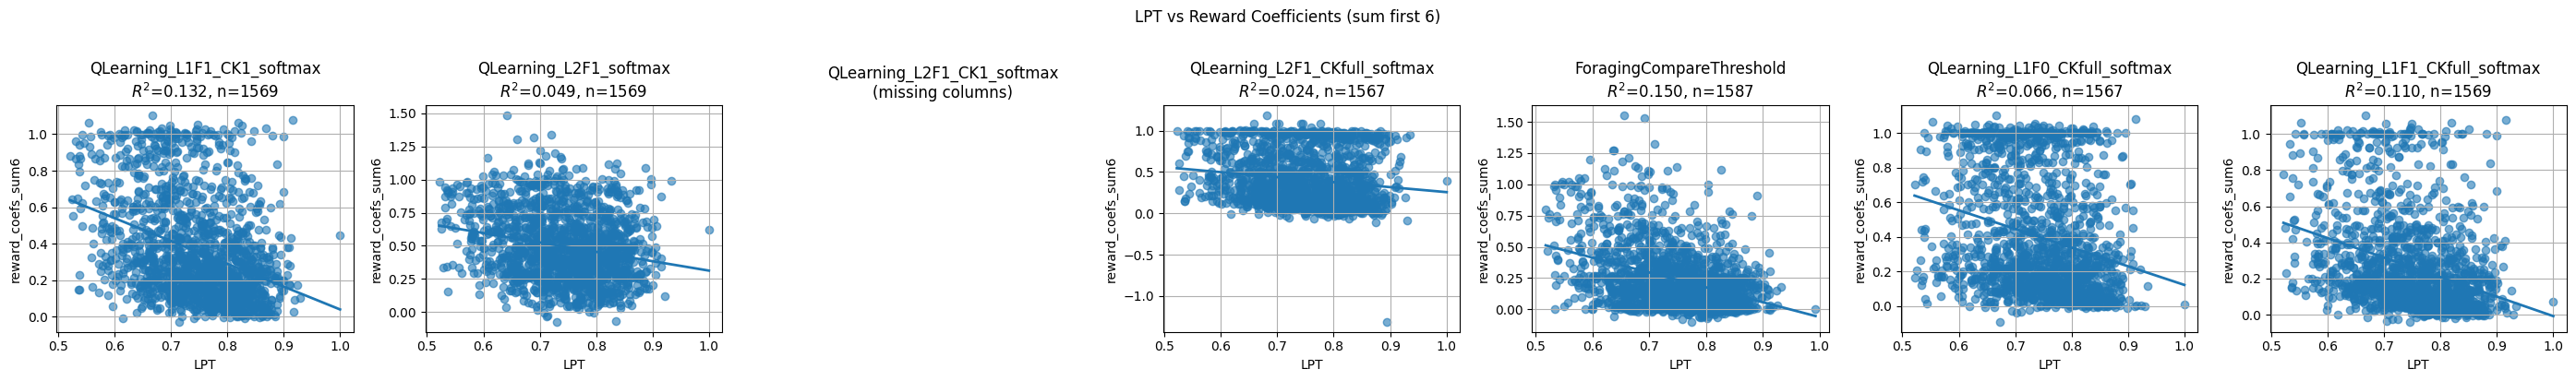

In [32]:
import importlib
import behavior_qc_visualization

importlib.reload(behavior_qc_visualization)

from behavior_qc_visualization import plot_x_vs_y_by_stage


# Only final / graduated stages
results = plot_x_vs_y_by_stage(
    summary,
    stage=["STAGE_FINAL"]
)




In [38]:
summary['logistic_bias']

0       0.299077
1       0.258081
2            NaN
3            NaN
4            NaN
          ...   
4382   -0.288340
4383   -0.476963
4384   -0.055170
4385    0.042799
4386   -0.021978
Name: logistic_bias, Length: 4387, dtype: float64

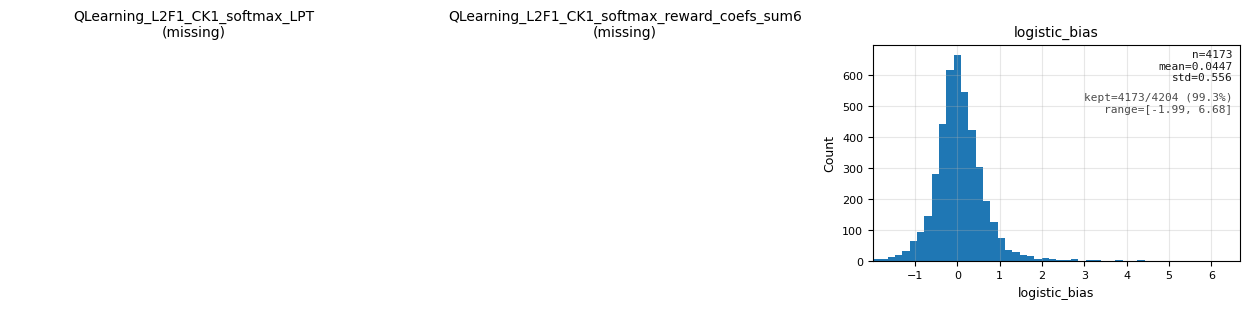

In [49]:
import importlib
import behavior_qc_visualization

importlib.reload(behavior_qc_visualization)

from behavior_qc_visualization import plot_summary_column_distributions


cols = [
    "QLearning_L2F1_CK1_softmax_LPT",
    "QLearning_L2F1_CK1_softmax_reward_coefs_sum6",
    "logistic_bias",
]
fig, axes, stats = plot_summary_column_distributions(
    summary, cols,
    bins=50, ncols=3,
    xlim_percentiles=(0.9, 99.9),
    xlim_pad_frac=0.05,
)

